# Day 4: Advanced Performance Analytics

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

os.makedirs('../reports', exist_ok=True)
os.makedirs('../reports/charts', exist_ok=True)

# Define paths
data_dir = '../data/processed'


## 1. Load Data

In [2]:
# Load NAV data
nav_df = pd.read_csv(f'{data_dir}/clean_nav_history.csv')
nav_df['date'] = pd.to_datetime(nav_df['date'])

# Load Fund Master
fund_master = pd.read_csv(f'{data_dir}/clean_fund_master.csv')

# Load Benchmark Indices
bench_df = pd.read_csv(f'{data_dir}/clean_benchmark_indices.csv')
bench_df['date'] = pd.to_datetime(bench_df['date'])

# Create a mapping dictionary for scheme names
amfi_to_name = fund_master.set_index('amfi_code')['scheme_name'].to_dict()


## 2. Calculate Daily Returns

In [3]:
# Pivot NAV data
nav_pivot = nav_df.pivot(index='date', columns='amfi_code', values='nav')
nav_pivot.columns = [amfi_to_name.get(col, col) for col in nav_pivot.columns]
nav_pivot.sort_index(inplace=True)

# Calculate Daily Returns
daily_returns = nav_pivot.pct_change().dropna(how='all')

print("Daily Returns Shape:", daily_returns.shape)
daily_returns.head()


Daily Returns Shape: (1149, 40)


,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,ABSL Frontline Equity Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Flexi Cap Fund - Regular - Growth,Nippon India Large Cap Fund - Regular - Growth,...,Kotak Flexicap Fund - Regular - Growth,Kotak Liquid Fund - Regular - Growth,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset Emerging Bluechip Fund - Regular - Growth,Mirae Asset Tax Saver Fund - Regular - Growth,DSP Top 100 Equity Fund - Regular - Growth,DSP Midcap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth
date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714,...,0.018160,0.000243,0.001001,-0.005010,0.019318,0.015865,0.008378,-0.008592,0.000482,-0.010498
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913,...,-0.012304,0.000462,0.004250,-0.005184,-0.003939,-0.007660,0.015294,-0.006480,0.008670,-0.002593
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540,...,0.008509,0.000650,-0.003589,-0.002706,0.011892,-0.004709,0.000863,-0.003818,-0.013861,-0.008382
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793,...,-0.013477,0.000176,-0.002719,-0.012660,0.000515,0.007001,0.001173,-0.004069,0.004317,0.011680
2022-01-10,-0.008639,0.006791,0.006277,0.011548,0.001251,0.000690,-0.001202,-0.000722,-0.011593,0.006360,...,-0.002583,0.000853,0.003057,-0.019536,0.024234,-0.011127,0.009372,0.001601,0.003650,0.001356


## 3. Calculate CAGR (1yr, 3yr, 5yr)

In [4]:
def calculate_cagr(df, years):
    end_date = df.index.max()
    start_date = end_date - pd.DateOffset(years=years)
    
    cagrs = {}
    for col in df.columns:
        valid_data = df[col].dropna()
        if len(valid_data) == 0:
            cagrs[col] = np.nan
            continue
            
        fund_end = valid_data.index.max()
        target_start = fund_end - pd.DateOffset(years=years)
        
        if target_start < valid_data.index.min():
            actual_start = valid_data.index.min()
        else:
            # First date on or after target_start
            actual_start = valid_data[valid_data.index >= target_start].index[0]
            
        val_start = valid_data.loc[actual_start]
        val_end = valid_data.loc[fund_end]
        
        actual_years = (fund_end - actual_start).days / 365.25
        
        if actual_years <= 0 or val_start <= 0:
            cagrs[col] = np.nan
        else:
            cagrs[col] = (val_end / val_start) ** (1 / actual_years) - 1
            
    return pd.Series(cagrs)

cagr_1yr = calculate_cagr(nav_pivot, 1)
cagr_3yr = calculate_cagr(nav_pivot, 3)
cagr_5yr = calculate_cagr(nav_pivot, 5) # Will compute over max available (~4 years)

cagr_df = pd.DataFrame({
    'CAGR_1yr': cagr_1yr,
    'CAGR_3yr': cagr_3yr,
    'CAGR_5yr_max': cagr_5yr
})
cagr_df.head()


,CAGR_1yr,CAGR_3yr,CAGR_5yr_max
HDFC Top 100 Fund - Regular Plan - Growth,-0.022258,0.012924,0.026371
HDFC Short Term Debt Fund - Regular - Growth,0.037076,0.039155,0.044582
HDFC Mid-Cap Opportunities Fund - Regular - Growth,0.532772,0.324340,0.301232
ABSL Frontline Equity Fund - Regular - Growth,0.479638,0.289602,0.235384
ABSL Small Cap Fund - Regular - Growth,-0.240003,-0.041515,0.079388


## 4. Compute Sharpe and Sortino Ratios

In [5]:
risk_free_rate = 0.065
daily_rf = (1 + risk_free_rate) ** (1/252) - 1

# Sharpe Ratio
ann_returns = daily_returns.mean() * 252
ann_volatility = daily_returns.std() * np.sqrt(252)
sharpe_ratio = (ann_returns - risk_free_rate) / ann_volatility

# Sortino Ratio
downside_returns = daily_returns.copy()
downside_returns[downside_returns > 0] = 0
downside_volatility = downside_returns.std() * np.sqrt(252)
sortino_ratio = (ann_returns - risk_free_rate) / downside_volatility

ratios_df = pd.DataFrame({
    'Sharpe_Ratio': sharpe_ratio,
    'Sortino_Ratio': sortino_ratio
})
ratios_df.head()


,Sharpe_Ratio,Sortino_Ratio
HDFC Top 100 Fund - Regular Plan - Growth,-0.201517,-0.357702
HDFC Short Term Debt Fund - Regular - Growth,-0.567095,-1.009643
HDFC Mid-Cap Opportunities Fund - Regular - Growth,1.093699,1.967316
ABSL Frontline Equity Fund - Regular - Growth,1.027213,1.889576
ABSL Small Cap Fund - Regular - Growth,0.162661,0.285576


## 5. Calculate Alpha and Beta against NIFTY 100

In [6]:
# Prepare NIFTY100
nifty100 = bench_df[bench_df['index_name'] == 'NIFTY100'].set_index('date')['close_value']
nifty100.sort_index(inplace=True)
nifty100_returns = nifty100.pct_change().dropna()

alphas = {}
betas = {}

for col in daily_returns.columns:
    merged = pd.concat([daily_returns[col], nifty100_returns], axis=1).dropna()
    if len(merged) < 50:
        alphas[col] = np.nan
        betas[col] = np.nan
        continue
        
    slope, intercept, r_value, p_value, std_err = stats.linregress(merged.iloc[:, 1], merged.iloc[:, 0])
    
    betas[col] = slope
    alphas[col] = intercept * 252 # Annualize alpha

alpha_beta_df = pd.DataFrame({
    'scheme_name': list(alphas.keys()),
    'Alpha': list(alphas.values()),
    'Beta': list(betas.values())
})

alpha_beta_df.to_csv('../reports/alpha_beta.csv', index=False)
alpha_beta_df.head()


,scheme_name,Alpha,Beta
0,HDFC Top 100 Fund - Regular Plan - Growth,0.037476,-0.058268
1,HDFC Short Term Debt Fund - Regular - Growth,0.042818,0.001158
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104
3,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086
4,ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289


## 6. Maximum Drawdown

In [7]:
rolling_max = nav_pivot.cummax()
drawdowns = (nav_pivot / rolling_max) - 1
max_drawdown = drawdowns.min()

max_dd_df = pd.DataFrame({'Max_Drawdown': max_drawdown})
max_dd_df.head()


,Max_Drawdown
HDFC Top 100 Fund - Regular Plan - Growth,-0.247344
HDFC Short Term Debt Fund - Regular - Growth,-0.043083
HDFC Mid-Cap Opportunities Fund - Regular - Growth,-0.162172
ABSL Frontline Equity Fund - Regular - Growth,-0.112916
ABSL Small Cap Fund - Regular - Growth,-0.354469


## 7. Fund Scorecard (0-100)

In [8]:
# Combine all metrics
scorecard = pd.concat([cagr_df, ratios_df, max_dd_df], axis=1)
scorecard = scorecard.merge(alpha_beta_df.set_index('scheme_name'), left_index=True, right_index=True)

# Add Expense Ratio
fund_master_idx = fund_master.set_index('scheme_name')
scorecard = scorecard.join(fund_master_idx['expense_ratio_pct'])

# Ranks
rank_3yr_ret = scorecard['CAGR_3yr'].rank(pct=True)
rank_sharpe = scorecard['Sharpe_Ratio'].rank(pct=True)
rank_alpha = scorecard['Alpha'].rank(pct=True)
rank_exp = scorecard['expense_ratio_pct'].rank(pct=True, ascending=False) # Lower is better
rank_dd = scorecard['Max_Drawdown'].rank(pct=True) # Higher (closer to 0) is better

# Composite Score: 30% × 3yr return + 25% × Sharpe + 20% × Alpha + 15% × inverse Expense Ratio + 10% × inverse Max DD
scorecard['Composite_Score'] = (
    0.30 * rank_3yr_ret + 
    0.25 * rank_sharpe + 
    0.20 * rank_alpha + 
    0.15 * rank_exp + 
    0.10 * rank_dd
) * 100

scorecard = scorecard.sort_values(by='Composite_Score', ascending=False)
scorecard.index.name = 'scheme_name'
scorecard.reset_index(inplace=True)

scorecard.to_csv('../reports/fund_scorecard.csv', index=False)
scorecard.head()


,scheme_name,CAGR_1yr,CAGR_3yr,CAGR_5yr_max,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Alpha,Beta,expense_ratio_pct,Composite_Score
0,Mirae Asset Large Cap Fund - Regular - Growth,0.203760,0.339920,0.309741,1.448291,2.609850,-0.112657,0.269838,0.023684,1.46,86.25
1,ICICI Pru Midcap Fund - Regular - Growth,0.296277,0.317692,0.328274,1.180101,2.158384,-0.181885,0.292636,0.000549,1.36,82.25
2,Kotak Flexicap Fund - Regular - Growth,0.266776,0.295751,0.309075,1.306744,2.463887,-0.129740,0.273305,-0.022830,1.45,82.00
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532772,0.324340,0.301232,1.093699,1.967316,-0.162172,0.271954,0.005104,1.38,80.75
4,ICICI Pru Bluechip Fund - Direct - Growth,0.130738,0.324789,0.232951,1.026524,1.877411,-0.125883,0.211948,0.016232,0.80,80.00


## 8. Benchmark Comparison Chart

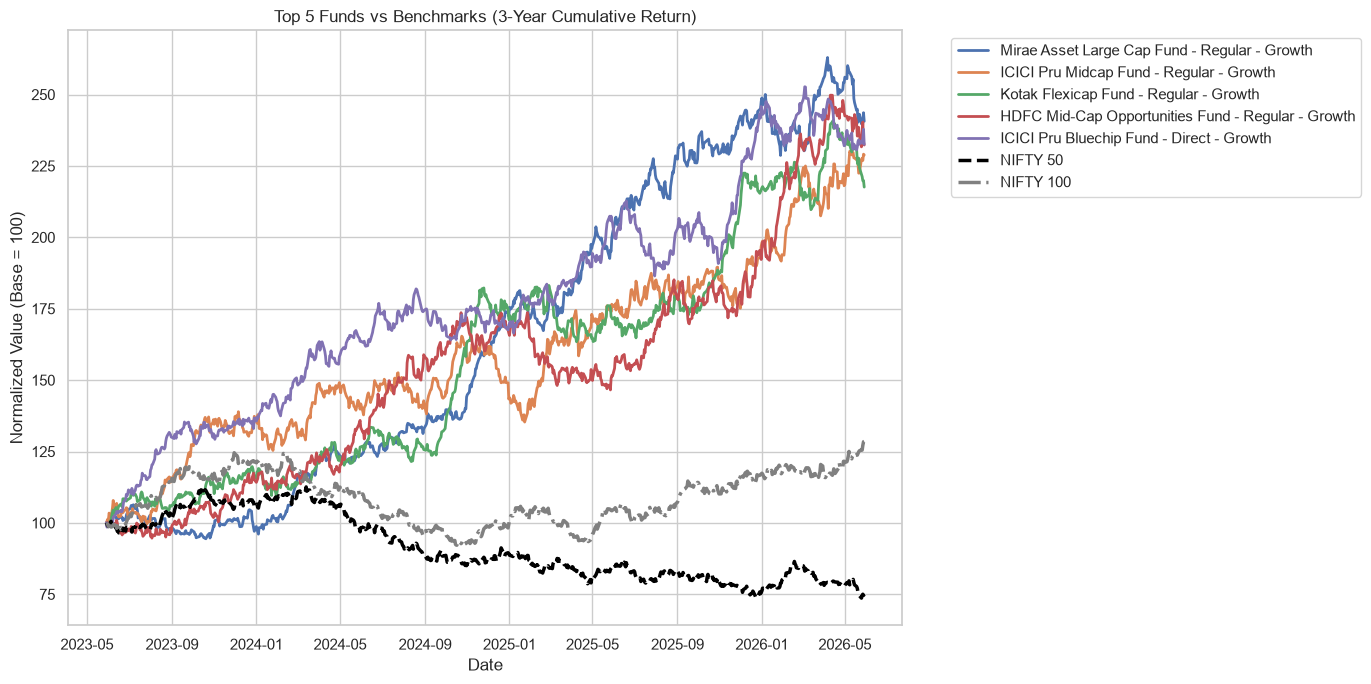

Tracking Error for Top 5 Funds:
                                                Fund  Tracking_Error
0      Mirae Asset Large Cap Fund - Regular - Growth        0.189664
1           ICICI Pru Midcap Fund - Regular - Growth        0.231968
2             Kotak Flexicap Fund - Regular - Growth        0.206425
3  HDFC Mid-Cap Opportunities Fund - Regular - Gr...        0.228699
4          ICICI Pru Bluechip Fund - Direct - Growth        0.191587


In [9]:
top_5_funds = scorecard.head(5)['scheme_name'].tolist()

# Get normalized cumulative returns over 3 years
end_date = nav_pivot.index.max()
start_date = end_date - pd.DateOffset(years=3)

# Filter data
nav_3y = nav_pivot.loc[start_date:end_date, top_5_funds].dropna(how='all')
if len(nav_3y) > 0:
    nav_3y = nav_3y / nav_3y.iloc[0] * 100

# Get benchmarks
nifty50 = bench_df[bench_df['index_name'] == 'NIFTY50'].set_index('date')['close_value']
nifty100 = bench_df[bench_df['index_name'] == 'NIFTY100'].set_index('date')['close_value']

bench_3y = pd.concat([nifty50, nifty100], axis=1, keys=['NIFTY50', 'NIFTY100'])
bench_3y = bench_3y.loc[start_date:end_date].dropna(how='all')
if len(bench_3y) > 0:
    bench_3y = bench_3y / bench_3y.iloc[0] * 100

plt.figure(figsize=(14, 7))

for fund in top_5_funds:
    if fund in nav_3y.columns:
        plt.plot(nav_3y.index, nav_3y[fund], label=fund, linewidth=2)

plt.plot(bench_3y.index, bench_3y['NIFTY50'], label='NIFTY 50', color='black', linestyle='--', linewidth=2.5)
plt.plot(bench_3y.index, bench_3y['NIFTY100'], label='NIFTY 100', color='gray', linestyle='-.', linewidth=2.5)

plt.title('Top 5 Funds vs Benchmarks (3-Year Cumulative Return)')
plt.xlabel('Date')
plt.ylabel('Normalized Value (Base = 100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('../reports/charts/benchmark_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Compute tracking error for top 5 funds vs NIFTY 100
tracking_errors = {}
for fund in top_5_funds:
    if fund in daily_returns.columns:
        diff = daily_returns[fund] - nifty100_returns
        tracking_errors[fund] = diff.std() * np.sqrt(252)

te_df = pd.DataFrame(list(tracking_errors.items()), columns=['Fund', 'Tracking_Error'])
print("Tracking Error for Top 5 Funds:")
print(te_df)
